Размеры изображения: (764, 700, 3)


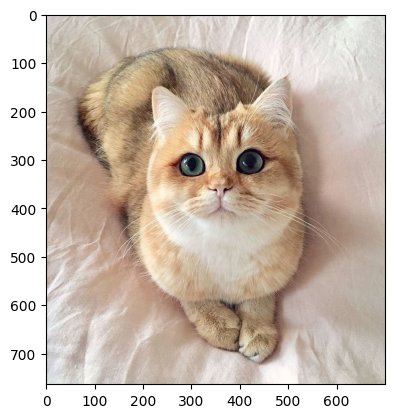

Время выполнения: 0.00827336311340332 c


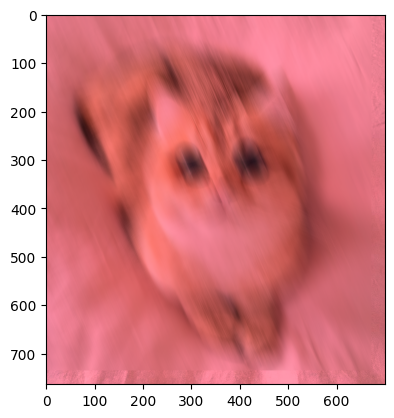

In [11]:
from PIL import Image # Python Image Library
from matplotlib import pyplot as plt
import numpy as np

from time import time # Для того, чтобы засекать время на выполнение операций

import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

imgRGB = np.array(Image.open('cat1.jpg'))
print('Размеры изображения:', imgRGB.shape)

plt.imshow(imgRGB)
plt.show()

def toneImg(image, rgbTone):
    """
    Эта функция тонирует RGB изображение, умножая весь массив
    на вектор коэффициентов rgbTone
    """
    return np.clip(image * rgbTone, 0, 255).astype(np.uint8)

def makeKernel(blurVector):
    """
    Эта функция создаёт ядро фильтра размытия по направлению
    на основе заданного вектора по XY
    """
    # Находим модули компонент вектора, чтобы по ним
    # найти размеры матрицы ядра
    blurVectorAbs  = np.abs(blurVector)
    # Определяем размеры четверти ядра по модулям компонент 
    kernelX = int(np.ceil(blurVectorAbs[0]))
    kernelY = int(np.ceil(blurVectorAbs[1]))
    # Создаём соответствующую нулевую матрицу
    kernelQuad = np.zeros((kernelY, kernelX), dtype=np.float32)
    # Заполняем диагональ единицами, проходя в цикле по наиболее
    # длинной стороне, чтобы не пропустить ни один элемент
    kernelForm = 'wide' if kernelY < kernelX else 'tall'
    if kernelForm == 'wide':
        for i in range(kernelX):
            j = int(i / kernelX * kernelY)
            kernelQuad[j,i] = 1.0
    elif kernelForm == 'tall':
        for j in range(kernelY):
            i = int(j / kernelY * kernelX)
            kernelQuad[j,i] = 1.0
    # Следующие две строки визуализируют построенную четверть ядра
    #plt.imshow(kernelQuad, cmap='Greys_r')
    #plt.show()
    # Создаём нулевую матрицу ядра
    kernel = np.zeros((2*kernelY+1, 2*kernelX+1), dtype=np.float32)
    # Записываем левую верхнюю и правую нижнюю четверти,
    # а также центральный пиксель
    kernel[0:kernelY,  0:kernelX]  = kernelQuad
    kernel[kernelY,    kernelX]    = 1.0
    kernel[kernelY+1:, kernelX+1:] = kernelQuad
    # Находим знаки компонент вектора, чтобы по ним
    # правильно отразить матрицу ядра
    blurVectorSign = np.sign(blurVector)
    # Отражаем матрицу так, чтобы её ненулевая диагональ совпала
    # по направлению с исходным вектором
    if blurVectorSign[0] == 1:    # нулевая компонента вектора - Х
        kernel = np.flip(kernel, axis=1)  # первая ось матрицы - Х
    # Поскольку строки матрицы идут сверху вниз, а Y – снизу вверх,
    # отражаем, когда Y компонента имеет знак +
    if blurVectorSign[1] == -1:    # первая компонента вектора - Y
        kernel = np.flip(kernel, axis=0) # нулевая ось матрицы - Y
    # Следующие две строки визуализируют построенное ядро
    #plt.imshow(kernel, cmap='Greys_r')
    #plt.show()
    return kernelX, kernelY, kernel

# Это нужно, если на компьютере стоит Visual Studio, которая старше, чем CUDA Toolkit
build_options = ["-allow-unsupported-compiler"]
# Код, который будет выполняться на каждом ядре видеокарты. Написан на CUDA C++
gpuCode = SourceModule("""
    __constant__ int kernelX;
    __constant__ int kernelY;
    __constant__ int NX; // image.shape[1]
    __constant__ int NY; // image.shape[0]
    __constant__ int KX; // kernel.shape[1] = 2*kernelX+1
    __constant__ int KY; // kernel.shape[0] = 2*kernelY+1

    // Эта функция вычисляет усреднённый по ядру цвет пикселя
    __global__ void motionBlurCoreGPU(unsigned char *image, float *kernel, unsigned char *imageBlurred)
    {   
        // Восстанавливаем двумерный индекс пикселя по размеру блока, его индексу в гриде и индексу потока в блоке
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        int j = blockDim.y * blockIdx.y + threadIdx.y;

        // Эти переменные будут двумерным индексом соседнего пикселя в пределах ядра
        int ki, kj;

        // В этой переменной будем подсчитывать ненулевые элементы ядра
        int kerNorm;
        // В этих переменных будем суммировать компоненты пикселей, соответствующих ненулевым элементам
        int rSum, gSum, bSum;
        // Это будут компоненты усреднённого пикселя
        float rBlurred, gBlurred, bBlurred;
        
        // Проверяем на всякий случай, что не вышли за пределы изображения
        if (i >= 0 && i < NX && j >= 0 && j < NY) 
        {
            kerNorm = 0;
            rSum = 0;
            gSum = 0;
            bSum = 0;
            // Перебираем все индексы пикселей в пределах ядра
            for (kj = j-kernelY; kj <= j+kernelY; kj++)
            {
                // Проверяем, не вышли ли за границы по строкам
                if (kj >= 0 && kj < NY)
                {
                    for (ki = i-kernelX; ki <= i+kernelX; ki++)
                    {
                        // Проверяем, не вышли ли за границы по столбцам
                        if (ki >= 0 && ki < NX)
                        {
                            // Вычисляем одномерный индекс элемента ядра, соответствующего пикселю ki,kj, и смотрим, нулевой он или нет
                            if (kernel[KX*(kj-j+kernelY) + (ki-i+kernelX)] > 0.0)
                            {
                                // Если ненулевой, считаем его в kerNorm
                                kerNorm++;
                                // И добавляем значения компонент пикселя ki,kj в суммы
                                // Для этого также вычисляем одномерный индекс каждой компоненты
                                rSum += image[NX*3*kj + ki*3 + 0];
                                gSum += image[NX*3*kj + ki*3 + 1];
                                bSum += image[NX*3*kj + ki*3 + 2];
                            }
                        }
                    }
                }
            }
            // На всякий случай проверяем, что ненулевые элементы в ядре были
            if (kerNorm > 0)
            {
                // Усредняем, явно приводя к float, чтобы не было целочисленного деления
                rBlurred = (float)rSum / (float)kerNorm;
                gBlurred = (float)gSum / (float)kerNorm;
                bBlurred = (float)bSum / (float)kerNorm;
                // Записываем цветовые компоненты пикселя, также вычисляя одномерный индекс каждой
                imageBlurred[NX*3*j + i*3 + 0] = (unsigned char)rBlurred;
                imageBlurred[NX*3*j + i*3 + 1] = (unsigned char)gBlurred;
                imageBlurred[NX*3*j + i*3 + 2] = (unsigned char)bBlurred;
            }
        }
    }
    """, options=build_options)

def runMotionBlurOnGPU(image, kernelX, kernelY, kernel):
    """
    Эта функция передаёт изображение и ядро на GPU и запускает параллельные вычисления 
    для выполнения размытия, после чего возвращает обратно результат
    """
    # Передаём массивы на device (на видеокарту)
    image_gpu        = cuda.mem_alloc(image.nbytes)
    imageBlurred_gpu = cuda.mem_alloc(image.nbytes)
    kernel_gpu       = cuda.mem_alloc(kernel.nbytes)
    cuda.memcpy_htod(image_gpu, image)
    cuda.memcpy_htod(imageBlurred_gpu, image)
    cuda.memcpy_htod(kernel_gpu, kernel)
    # Передаём константы на device (на видеокарту)
    nx_gpu = gpuCode.get_global('NX')[0]
    ny_gpu = gpuCode.get_global('NY')[0]
    kx_gpu = gpuCode.get_global('KX')[0]
    ky_gpu = gpuCode.get_global('KY')[0]
    kernelx_gpu = gpuCode.get_global('kernelX')[0]
    kernely_gpu = gpuCode.get_global('kernelY')[0]
    # Константы с несовпадающим типом передаём как numpy массив из одного элемента с нужным типом
    cuda.memcpy_htod(nx_gpu, np.full(1, image.shape[1],  dtype=np.int32))
    cuda.memcpy_htod(ny_gpu, np.full(1, image.shape[0],  dtype=np.int32))
    cuda.memcpy_htod(kx_gpu, np.full(1, kernel.shape[1], dtype=np.int32))
    cuda.memcpy_htod(ky_gpu, np.full(1, kernel.shape[0], dtype=np.int32))
    cuda.memcpy_htod(kernelx_gpu, np.full(1, kernelX, dtype=np.int32))
    cuda.memcpy_htod(kernely_gpu, np.full(1, kernelY, dtype=np.int32))
    # Задаём число потоков в блоке и число блоков в гриде
    blockdim = 32, 32, 1
    griddim = int(image.shape[1]/blockdim[1]), int(image.shape[0]/blockdim[0]), 1
    # Получаем ссылку на функцию обработки пикселя в коде на GPU и запускаем её
    motionBlurCoreGPU = gpuCode.get_function("motionBlurCoreGPU")
    motionBlurCoreGPU(image_gpu, kernel_gpu, imageBlurred_gpu, block=blockdim, grid=griddim)
    # Передаём результат обратно на host
    imageBlurred = np.empty_like(image)
    cuda.memcpy_dtoh(imageBlurred, imageBlurred_gpu)
    return imageBlurred

# Задаём вектор тонирующих коэффициентов
toneVector = np.array([1.1, 0.6, 0.7])

# Задаём вектор размытия по XY
blurVector = np.array([-10.5, 25.1])

# Запускаем процесс тонирования
tonedImage = toneImg(imgRGB, toneVector)

# Создаём ядро по вектору размытия
kernelX, kernelY, kernel = makeKernel(blurVector)

# Запускаем процесс размытия, с распараллеливанием на CUDA GPU
start = time()
blurredImage = runMotionBlurOnGPU(tonedImage, kernelX, kernelY, kernel)
print('Время выполнения:', time()-start, 'c')

plt.imshow(blurredImage)
plt.show()

In [8]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


In [10]:
%cd /content/Energy
!git pull

/content/EnergyCraft
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 9 (delta 5), reused 9 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 389.35 KiB | 5.64 MiB/s, done.
From https://github.com/Killvarus/EnergyCraft
   4d2906c..93989b7  main       -> origin/main
Updating 4d2906c..93989b7
Fast-forward
 Dz.ipynb            | 340 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 cat.jpg => cat1.jpg | Bin
 2 files changed, 340 insertions(+)
 rename cat.jpg => cat1.jpg (100%)


In [9]:
!git clone https://github.com/Killvarus/EnergyCraft

fatal: destination path 'EnergyCraft' already exists and is not an empty directory.


In [4]:
pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=89291f5b02363822c6175ef4da35b5b5a45abea66c3b3fb6195defa65a747604
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [6]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [51]:
!ls -la

total 300
drwxr-xr-x 4 root root   4096 Mar 10 11:14 .
drwxr-xr-x 1 root root   4096 Mar 10 11:14 ..
-rw-r--r-- 1 root root   2200 Mar 10 11:14 2.1_scalar_operations.py
-rw-r--r-- 1 root root    959 Mar 10 11:14 2.2_vector_operations.py
-rw-r--r-- 1 root root   6714 Mar 10 11:14 2.3_blur.py
-rw-r--r-- 1 root root   7003 Mar 10 11:14 2.4_blur_cpu_parallel.py
-rw-r--r-- 1 root root  11537 Mar 10 11:14 2.5_blur_cuda.py
-rw-r--r-- 1 root root 246747 Mar 10 11:14 cat.jpg
-rw-r--r-- 1 root root      0 Mar 10 11:14 Dz.ipynb
drwxr-xr-x 5 root root   4096 Mar 10 11:14 EnergyCraft
drwxr-xr-x 8 root root   4096 Mar 10 11:28 .git
-rw-r--r-- 1 root root    335 Mar 10 11:14 .gitignore
